In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [188]:
df = pd.DataFrame(pd.read_csv('/home/zeus/programming/python/data/placement (1).csv'))

In [189]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


np.float64(1.632993161855452)

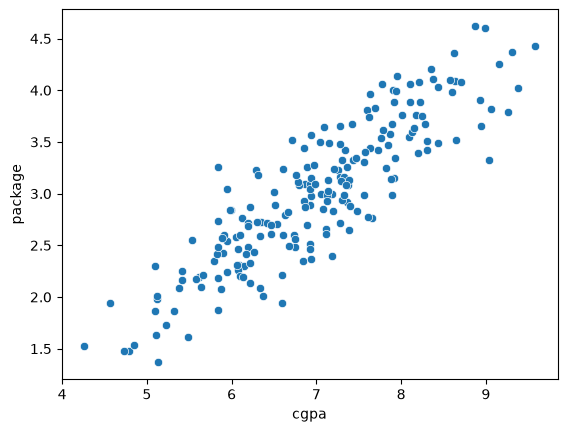

In [190]:
sns.scatterplot(data=df, x='cgpa', y='package')
n = [10,13,15]
g = [8,10,12]
arr = np.array(n)
arr1 = np.array(g)
arr.std()
arr1.std()

In [191]:
x = df.iloc[:,0].values
y = df.iloc[:,1].values
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.4, random_state=2)

In [192]:
sc = StandardScaler()

In [193]:
xTrain = xTrain.reshape(-1,1)

In [194]:
xTrain = sc.fit_transform(xTrain)

In [195]:
xTest = xTest.reshape(-1,1)

In [196]:
xTest = sc.transform(xTest)

In [197]:
reg = LinearRegression()

In [198]:
reg.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.57]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.041
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[10.95]


In [199]:
new_students = [
    7.6,
    9.5,
    5.2,
    2.5
]

new_students = np.array(new_students)
new_students = new_students.reshape(-1,1)
new_students = sc.transform(new_students)

predictions = reg.predict(new_students)

print(predictions)

[3.355929   4.40389245 2.0321857  0.54297449]


In [200]:
yPred = reg.predict(xTest)

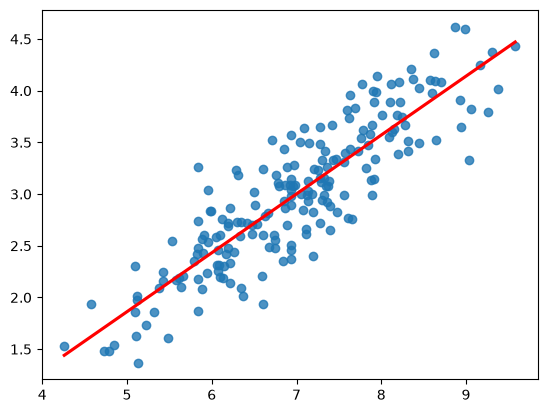

In [201]:
sns.regplot(x=x, y=y, ci=None, line_kws={"color": "red"})
plt.show()

In [202]:
from sklearn import metrics

In [203]:
MSE = metrics.mean_squared_error(yTest, yPred)
MSE

0.101018160069545

In [204]:
RMSE = np.sqrt(MSE)

In [205]:
RMSE

np.float64(0.3178335414482635)

In [206]:
R2 = metrics.r2_score(yTest, yPred)
R2

0.8058707521870406